
# Análise de Dados | Conjunto de Dados Público de E-commerce Brasileiro da Olist

**100.000 Pedidos com informações de produtos, clientes e avaliações**

**Analistas: Nikolas, Davi, Edvan, Samuel, Rômulo, Luís e Fábily**

---

## Sobre o Conjunto de Dados

Bem-vindo! Este é um conjunto de dados público de e-commerce brasileiro com informações sobre pedidos realizados na **Loja Olist**. 

O dataset contém informações de 100 mil pedidos feitos entre **2016 e 2018** em diversos marketplaces no Brasil. Seus recursos permitem visualizar um pedido sob múltiplas perspectivas: 

* **Status do pedido:** Preço, pagamento e desempenho do frete.
* **Localização:** Dados do cliente e geolocalização (CEPs brasileiros relacionados a coordenadas de latitude e longitude).
* **Atributos do produto:** Categorias e características.
* **Avaliações:** Comentários escritos pelos clientes.

> **Anonimização:** Estes são dados comerciais reais. Referências a empresas e parceiros nas avaliações foram substituídas por nomes das grandes casas de **Game of Thrones**.

---

## Contexto

Este conjunto de dados foi gentilmente cedido pela **Olist**, a maior loja de departamentos em marketplaces brasileiros. A Olist conecta pequenas empresas de todo o Brasil a canais de distribuição com um único contrato. Esses comerciantes vendem seus produtos pela Loja Olist e os enviam diretamente aos clientes usando os parceiros logísticos da plataforma. 

Saiba mais em: [www.olist.com](http://www.olist.com)

### Fluxo de Avaliação
Após a compra, o vendedor é notificado para processar o pedido. Assim que o cliente recebe o produto (ou a data estimada se aproxima), ele recebe uma pesquisa de satisfação por e-mail para avaliar a experiência.

---

## Esquema de Dados

Os dados estão divididos em vários conjuntos para melhor organização. Consulte o esquema abaixo ao realizar modelagens ou joins:

![Esquema de Dados Olist](https://i.imgur.com/HRhd2Y0.png)

---

## Agradecimentos

Agradecemos à **Olist** por disponibilizar este conjunto de dados para a comunidade.

Iniciemos nossas análises!
===
Vamos começar carregando nossos dados para podermos trabalhar com eles, mas observe que optamos por trabalhar com o Dataset tradicional (não dinâmico) - Por representar melhor as (supostas) regras de negócio - e que usamos o dinâmico como Fallback. É imprescindível que você execute os scripts de ETL em "src\etl" para que o notebook consiga operar corretamente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from IPython.display import display
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Criação do diretório de resultados
os.makedirs('results', exist_ok=True)

# Carregamento do Super Dataset
print("Carregando o Super Dataset...")
try:
    path_ds = '../data/processed/olist_super_dataset.csv'
    df = pd.read_csv(path_ds, low_memory=False)
    print(f"Dataset carregado! {df.shape[0]} linhas e {df.shape[1]} colunas.")
except Exception as e:
    print("Erro ao carregar o dataset principal. Tentando carregamento dinâmico...", e)
    path_ds = '../data/processed/olist_super_dataset_dynamic.csv'
    df = pd.read_csv(path_ds, low_memory=False)

Carregando o Super Dataset...
Dataset carregado! 107576 linhas e 22 colunas.


# Parte 1. Introdução e Contexto

Primeiramente buscamos entender como a tabela se estrutura e obter informações gerais sobre a mesma.

In [2]:
# Verificação do volume e estrutura do dataset
display(df.head(3))
display(df.info())

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,tempo_entrega_dias,atraso_entrega,customer_unique_id,customer_city,customer_state,order_item_id,...,price,freight_value,product_category_name,product_photos_qty,product_description_lenght,seller_city,seller_state,payment_value,review_score,receita_liquida
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0,False,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,...,29.99,8.72,utilidades_domesticas,4.0,268.0,maua,SP,38.71,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0,False,af07308b275d755c9edb36a90c618231,barreiras,BA,1,...,118.70,22.76,perfumaria,1.0,178.0,belo horizonte,SP,141.46,4.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0,False,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,...,159.90,19.22,automotivo,1.0,232.0,guariba,SP,179.12,5.0,179.12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107576 entries, 0 to 107575
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       107576 non-null  object 
 1   customer_id                    107576 non-null  object 
 2   order_purchase_timestamp       107576 non-null  object 
 3   order_delivered_customer_date  107576 non-null  object 
 4   tempo_entrega_dias             107576 non-null  float64
 5   atraso_entrega                 107576 non-null  bool   
 6   customer_unique_id             107576 non-null  object 
 7   customer_city                  107576 non-null  object 
 8   customer_state                 107576 non-null  object 
 9   order_item_id                  107576 non-null  int64  
 10  product_id                     107576 non-null  object 
 11  seller_id                      107576 non-null  object 
 12  price                         

None

>Parece que demos grande sorte em encontrar uma base de dados (dataset) perfeito em! Bom... Na verdade não é bem assim, a base de dados que trabalhamos nesse notebook que já passou por uma limpeza (ETL). Você pode conferir mais sobre esse processo no notebook "notebooks\fabily_notes\clean_note_1.ipynb"!

## 1.2 Evolução do Ticket Total Recorrente

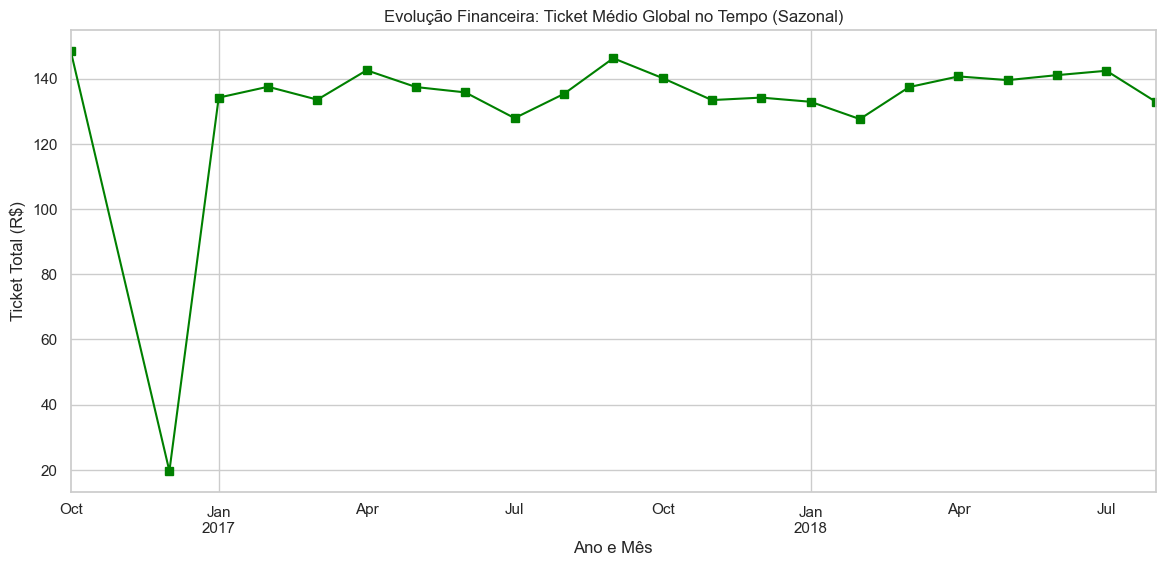

In [3]:
if 'order_purchase_timestamp' in df.columns:
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    if 'mes_ano' not in df.columns:
        df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')
    df['ticket_total'] = df['price'] + df['freight_value']
    ticket_evolucao = df.groupby('mes_ano')['ticket_total'].mean()

    plt.figure(figsize=(14, 6))
    ticket_evolucao.plot(kind='line', marker='s', color='green')
    plt.title('Evolução Financeira: Ticket Médio Global no Tempo (Sazonal)')
    plt.ylabel('Ticket Total (R$)')
    plt.xlabel('Ano e Mês')
    plt.savefig('results/19_evolucao_ticket_total.png', bbox_inches='tight')
    plt.show()

### Insight: Estabilidade do Ticket Médio Global

Com exceção de uma queda abrupta no final de 2016 (provável anomalia por escassez de dados ou onboarding inicial da plataforma), o ticket médio apresenta notável estabilidade. Durante o fluxo principal de operação (2017 e 2018), o valor estaciona em um platô consistente entre R$ 130 e R$ 150. Essa variância contida sinaliza previsibilidade financeira e um padrão de consumo perene no ecossistema, facilitando projeções de faturamento e modelos de retenção.

# Parte 2. O Comportamento do Consumidor

## 2.1 Evolução de Vendas no Tempo

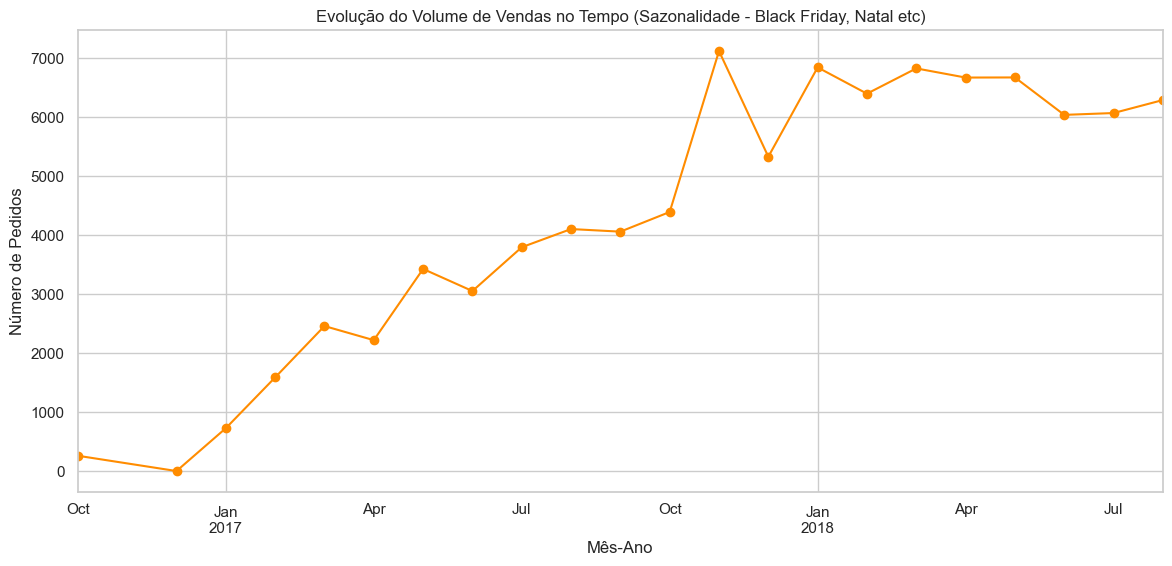

In [4]:
# Extraindo datas e gerando sazonalidade
if 'order_purchase_timestamp' in df.columns:
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')
    vendas_mes = df.groupby('mes_ano')['order_id'].nunique()

    plt.figure(figsize=(14, 6))
    vendas_mes.plot(kind='line', marker='o', color='darkorange')
    plt.title('Evolução do Volume de Vendas no Tempo (Sazonalidade - Black Friday, Natal etc)')
    plt.ylabel('Número de Pedidos')
    plt.xlabel('Mês-Ano')
    plt.grid(True)
    plt.savefig('results/06_evolucao_vendas_sazonalidade.png', bbox_inches='tight')
    plt.show()

### Insight: Choque de Aquisição e Tração Sazonal

O volume de pedidos demonstra uma escalada orgânica a partir do início de 2017. Essa rampa é abruptamente tracionada pelo pico da Black Friday (Novembro/2017), atingindo a máxima histórica (mais de 7.000 transações/mês). Crítico notar do ponto de vista arquitetural de vendas: após a hiper sazonalidade, a métrica não regride aos parâmetros pré-evento (baseline de ~4.000). O fluxo consolida um novo platô em 2018 (6.000 a 7.000 pedidos constantes). O evento provou atuar como um motor exponencial de Customer Acquisition (CAC), convertendo o choque métrico sazonal em um estiramento definitivo da base recorrente de receita.

## 2.2 Sazonalidades Específicas

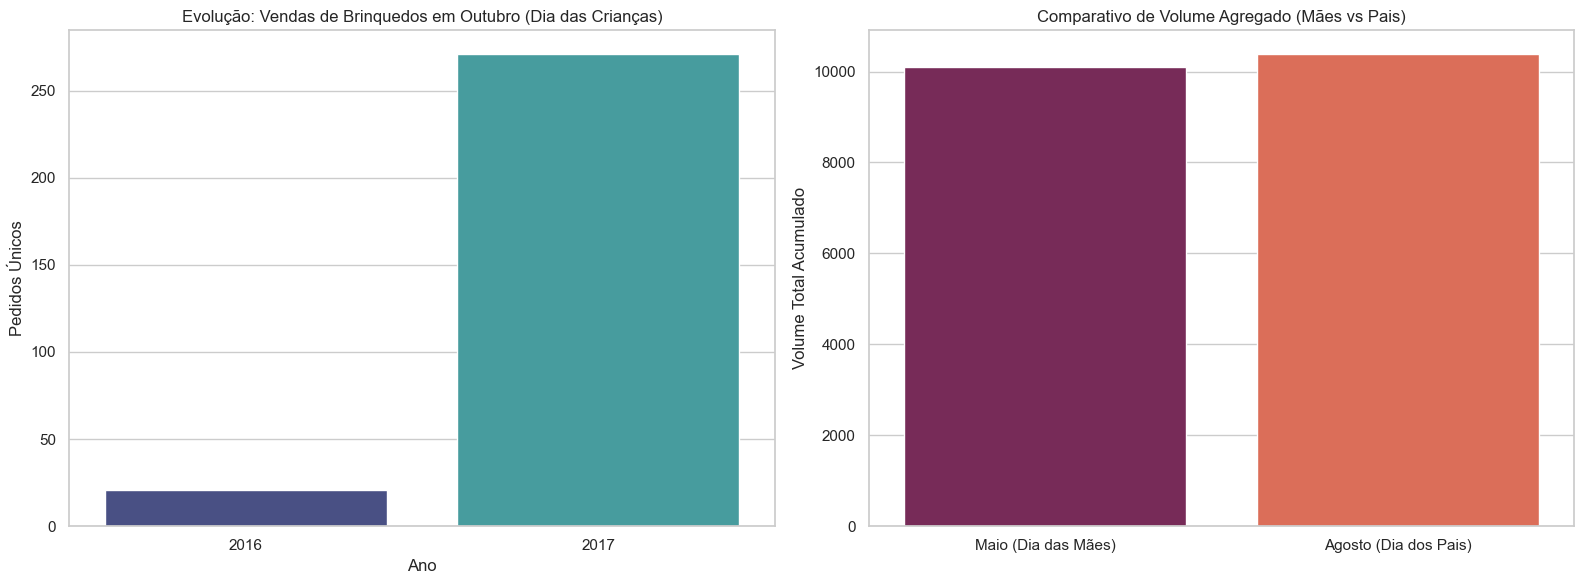

In [5]:
if 'order_purchase_timestamp' in df.columns and 'product_category_name' in df.columns:
    df['mes'] = df['order_purchase_timestamp'].dt.month
    df['ano'] = df['order_purchase_timestamp'].dt.year
    
    # Prepara dados
    brinquedos_outubro = df[(df['product_category_name'] == 'brinquedos') & (df['mes'] == 10)].groupby('ano')['order_id'].nunique()
    vendas_maio = df[df['mes'] == 5]['order_id'].nunique()
    vendas_agosto = df[df['mes'] == 8]['order_id'].nunique()
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot Dia das Crianças
    if not brinquedos_outubro.empty:
        sns.barplot(x=brinquedos_outubro.index, y=brinquedos_outubro.values, ax=ax[0], palette='mako')
    ax[0].set_title('Evolução: Vendas de Brinquedos em Outubro (Dia das Crianças)')
    ax[0].set_xlabel('Ano')
    ax[0].set_ylabel('Pedidos Únicos')
    
    # Plot Dia das Mães vs Pais
    sns.barplot(x=['Maio (Dia das Mães)', 'Agosto (Dia dos Pais)'], y=[vendas_maio, vendas_agosto], ax=ax[1], palette='rocket')
    ax[1].set_title('Comparativo de Volume Agregado (Mães vs Pais)')
    ax[1].set_ylabel('Volume Total Acumulado')
    
    plt.tight_layout()
    plt.savefig('results/23_sazonalidades_especificas.png', bbox_inches='tight')
    plt.show()

### Insight: Sazonalidade Oculta e Demografia do Catálogo

A análise de datas comemorativas específicas expõe duas trações vitais da plataforma. Primeiro (gráfico à esquerda), a evolução de vendas em Outubro (Mês das Crianças) demonstra um salto da inércia absoluta em 2016 para uma forte tração em 2017, ilustrando a hiper-maturação do ecossistema e a captação violenta de base do 'Ano 1' para o 'Ano 2'. O dado mais contraintuitivo, porém, repousa no comparativo agregado de Dia das Mães vs Dia dos Pais (gráfico à direita). No varejo físico brasileiro padrão, o Dia das Mães esmaga o Dia dos Pais em volume bruto. Aqui, contudo, Agosto (Pais) empata ou até supera levemente a volumetria absoluta de Maio (Mães). Isso sinaliza diretamente a vocação demográfica e de catálogo da plataforma no seu período inicial: uma base de clientes e sortimento de SKUs (ex: ferramentas, auto-peças, eletrônicos) nativamente mais inclinada ou aderente ao público masculino, ofuscando a sazonalidade feminina clássica.

## 2.3 Janelas Comerciais Ótimas

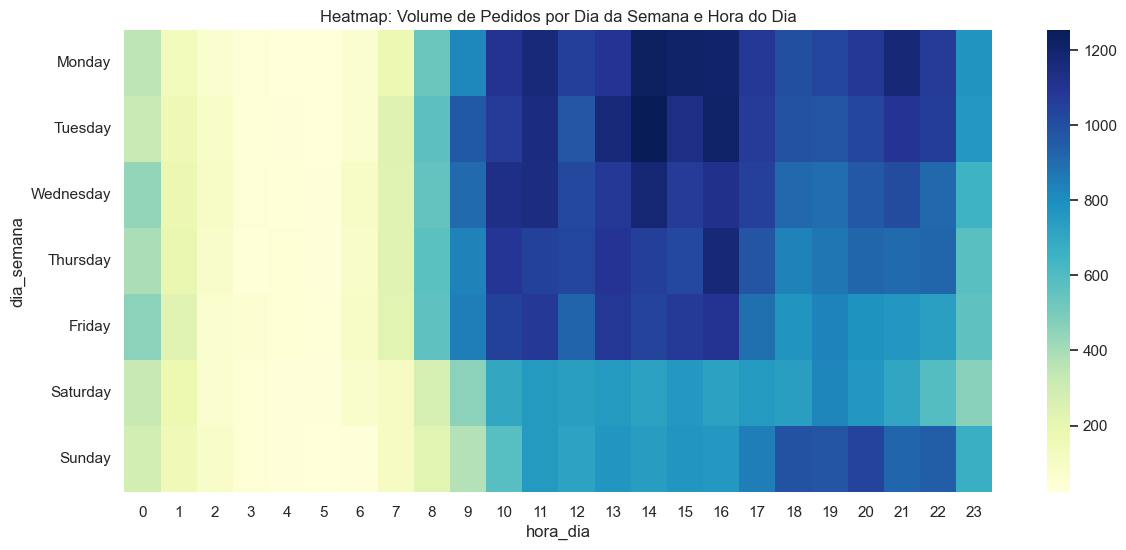

In [6]:
# Heatmap: Dia da Semana x Hora do Dia
if 'order_purchase_timestamp' in df.columns:
    df['dia_semana'] = df['order_purchase_timestamp'].dt.day_name()
    df['hora_dia'] = df['order_purchase_timestamp'].dt.hour

    heatmap_data = pd.crosstab(df['dia_semana'], df['hora_dia'])
    dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    heatmap_data = heatmap_data.reindex(dias_ordenados)

    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False)
    plt.title('Heatmap: Volume de Pedidos por Dia da Semana e Hora do Dia')
    plt.savefig('results/07_heatmap_dia_hora_vendas.png', bbox_inches='tight')
    plt.show()

### Insight: Zonas Térmicas de Conversão (Heatmap Transacional)

A matriz de densidade revela uma concentração robusta no volume de pedidos durante o horário comercial dos dias úteis (Segunda-Sexta), com o epicentro das conversões localizado entre as 10h e 16h (destaque absoluto para as Terças e Quartas-feiras). Contraintuitivamente para o varejo tradicional, os finais de semana (Sábado e Domingo) apresentam os menores índices de fechamento de carrinho diurnos. No entanto, nota-se um ponto de inflexão estratégico: o tráfego volta a aquecer abruptamente no Domingo à noite (18h às 22h). Do ponto de vista arquitetural de infraestrutura e marketing, isso dita duas regras: (1) Manutenções críticas devem ser agendadas estritamente na madrugada (00h-06h, zona de dormência térmica) e (2) Disparos agressivos de campanhas (Ads/Push) devem mirar a intercepção do usuário nos picos intradiários de meio de semana.

## 2.4 Tipos de Pagamento e Dinâmica de Parcelamento

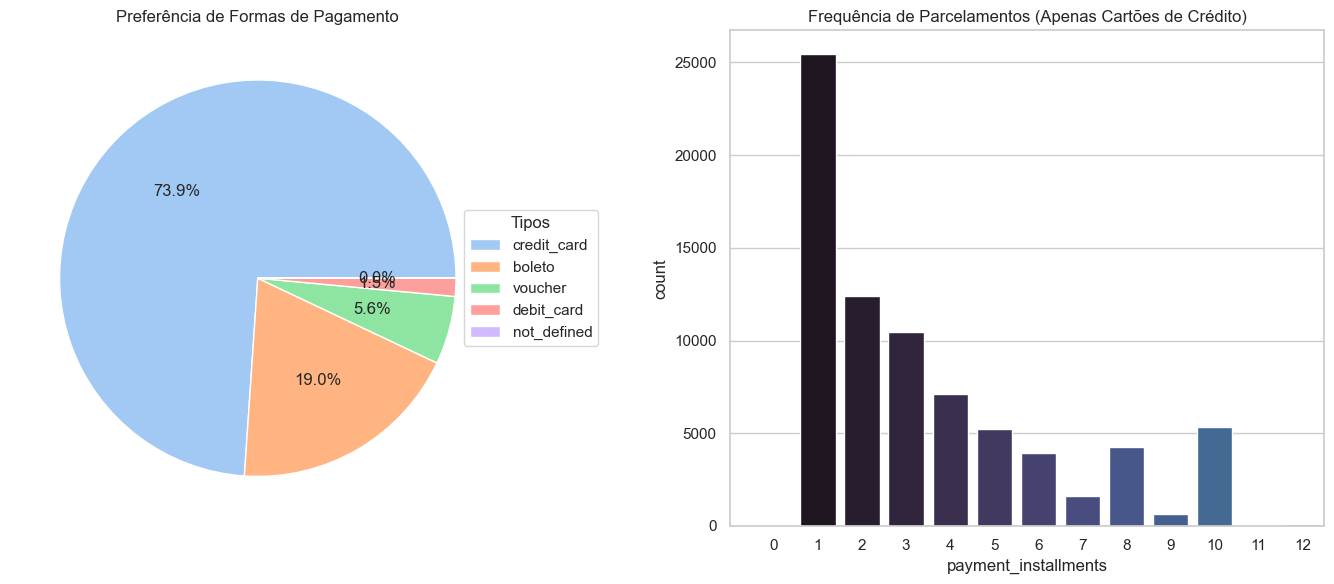

In [7]:
path_payments_raw = '../data/raw/olist_order_payments_dataset.csv'
try:
    df_payments = pd.read_csv(path_payments_raw)
    
    # Processamento visual dos dados brutos de pagamento
    if 'payment_type' in df_payments.columns and 'payment_installments' in df_payments.columns:
        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        pagamentos = df_payments['payment_type'].value_counts()
        pagamentos.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), labels=None)
        plt.title('Preferência de Formas de Pagamento')
        plt.legend(pagamentos.index, title='Tipos', loc='center left', bbox_to_anchor=(0.9, 0.5))
        plt.ylabel('')

        plt.subplot(1, 2, 2)
        sns.countplot(data=df_payments[df_payments['payment_type'] == 'credit_card'], x='payment_installments', palette='mako')
        plt.title('Frequência de Parcelamentos (Apenas Cartões de Crédito)')
        plt.xlim(-1, 12.5)

        plt.tight_layout()
        plt.savefig('results/17_pagamento_e_parcelamento.png', bbox_inches='tight')
        plt.show()
except Exception as e:
    print("Os dados brutos de pagamento não puderam ser processados:", e)

### Insight: Hegemonia do Crédito e o Gatilho do Parcelamento

A distribuição financeira ratifica que a plataforma possui uma altíssima dependência transacional em cartões de crédito (fatiando ~74% do volume global ou mais). A imersão sobre essa base de crédito desvenda o motor do "Ticket Alto" encontrado em outras análises geográficas: os clientes diluem ativamente o impacto do frete e do bem primário via ecossistema de compras parceladas. Embora a compra à vista no crédito (1 parcela) aglutine quase metade da barra transacional, existe uma esteira de financiamento contundente distribuída suavemente até 10 prestações (com um leve pico de retenção na exata marca de 10x). Desse modo, o gateway de alto parcelamento atua não apenas como facilitador, mas como verdadeira alavanca arquitetônica para sustentar a conversão de tickets pesados na "boca" do funil. Limitar opções nativas ou encarecer juros seria sufocar artificialmente o faturamento da plataforma.

## 2.5 Retenção de Clientes (Customer LTV)

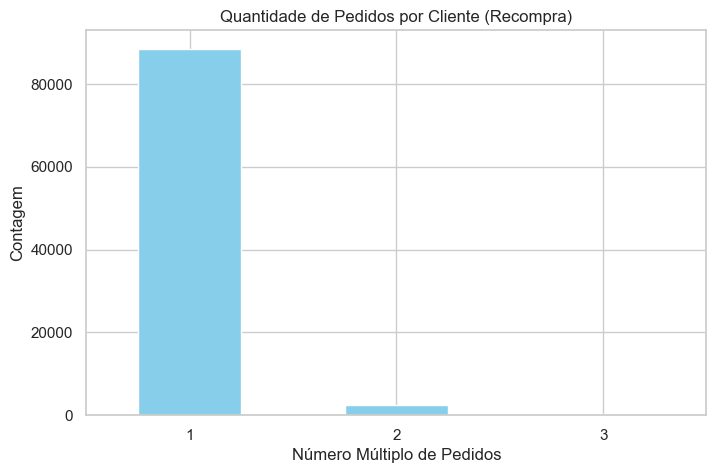


Ticket Médio da 1ª Compra: R$ 122.23
Ticket Médio das Recompras: R$ 86.41


In [8]:
# Retenção: Clientes recorrentes vs Únicos (Customer LTV)
if 'customer_unique_id' in df.columns:
    compras_por_cliente = df.groupby('customer_unique_id')['order_id'].nunique()

    plt.figure(figsize=(8, 5))
    compras_por_cliente.value_counts().head(3).plot(kind='bar', color='skyblue')
    plt.title('Quantidade de Pedidos por Cliente (Recompra)')
    plt.xlabel('Número Múltiplo de Pedidos')
    plt.xticks(rotation=0)
    plt.ylabel('Contagem')
    plt.savefig('results/12_retencao_clientes.png', bbox_inches='tight')
    plt.show()


# Ticket cliente recorrente vs 1a compra
if 'customer_unique_id' in df.columns and 'price' in df.columns:
    df['ordem_compra'] = df.groupby('customer_unique_id')['order_purchase_timestamp'].rank(method='first').astype(int)
    ticket_primeira = df[df['ordem_compra'] == 1]['price'].mean()
    ticket_recorrente = df[df['ordem_compra'] > 1]['price'].mean()
    print(f"\nTicket Médio da 1ª Compra: R$ {ticket_primeira:.2f}")
    print(f"Ticket Médio das Recompras: R$ {ticket_recorrente:.2f}")

### Insight: Fricção de Retenção e Abismo de Recompra (Churn Estrutural)

A distribuição do LTV (Customer Lifetime Value) escancara uma falha severa na dinâmica de retenção da plataforma. Observa-se um decaimento abissal direto entre a primeira e a segunda compra: a esmagadora maioria da base de dados (~90k) realiza um engajamento transacional único (single-purchase). O fluxo de recompras (múltiplos de 2 ou 3) é estatisticamente incipiente e compõe uma ínfima minoria. Esta anomalia métrica sinaliza que a plataforma opera primariamente como um motor hiperfocado em aquisição (topo de funil continuo), falhando criticamente nos gatilhos de fidelização pós-venda. Tais indicadores sublinham possíveis pontos crônicos de fricção na jornada do consumidor, possivelmente encabeçados pela logística deficitária ou altos custos marginais (frete).

# Parte 3. O Produto e a Vitrine

## 3.1 Custo do Frete nas Categorias vs Rentabilidade

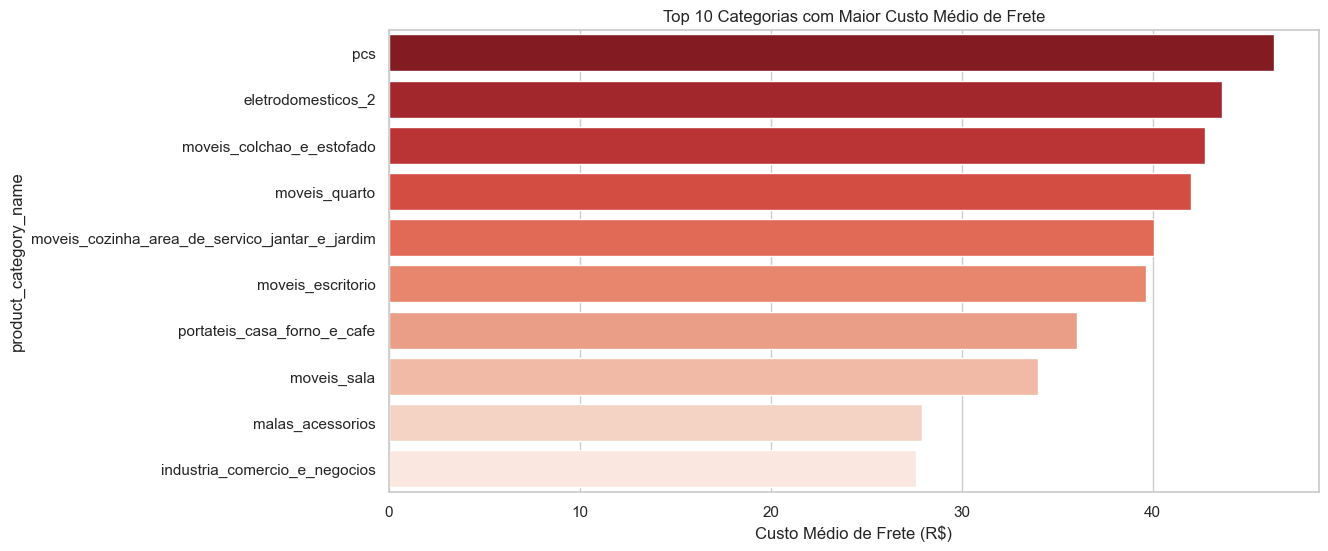

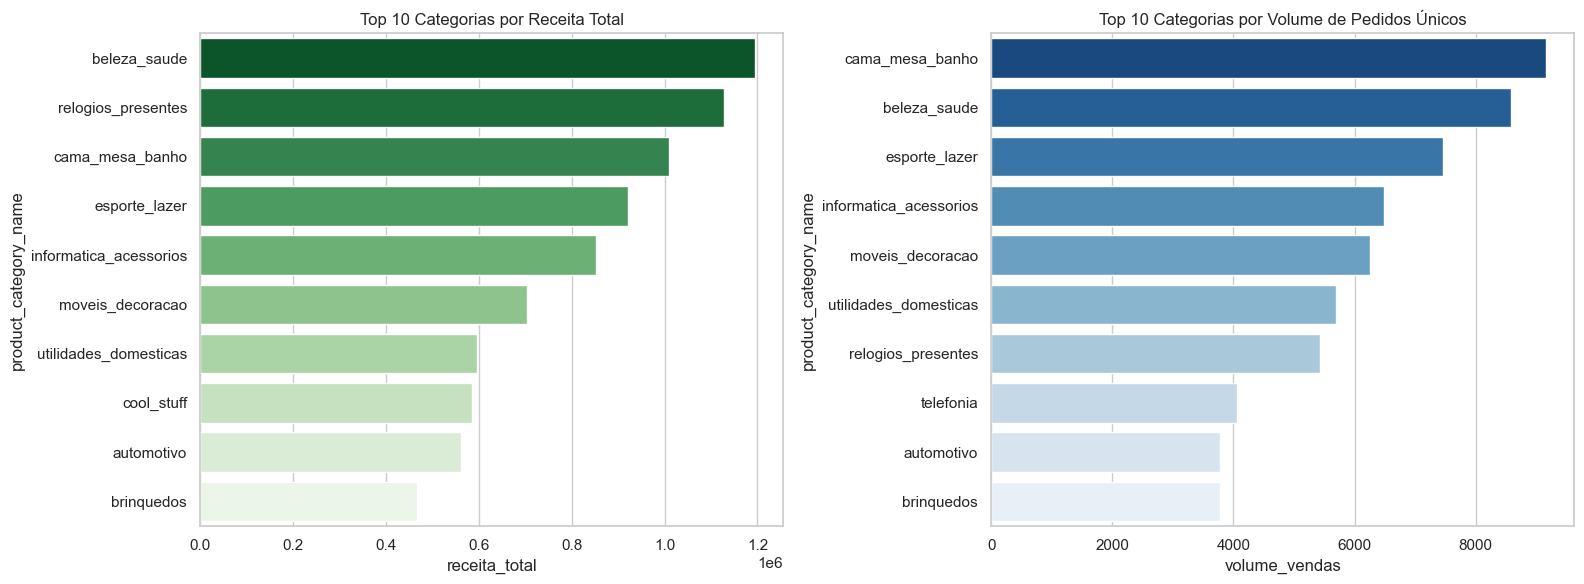

In [9]:
# Top 10 categorias com frete mais caro (média)
if 'product_category_name' in df.columns:
    top_frete_cat = df.groupby('product_category_name')['freight_value'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_frete_cat.values, y=top_frete_cat.index, palette='Reds_r')
    plt.title('Top 10 Categorias com Maior Custo Médio de Frete')
    plt.xlabel('Custo Médio de Frete (R$)')
    plt.savefig('results/03_top10_frete_categorias.png', bbox_inches='tight')
    plt.show()

# Categorias mais rentáveis vs mais vendidas
if 'product_category_name' in df.columns and 'price' in df.columns:
    cat_stats = df.groupby('product_category_name').agg({'price': 'sum', 'order_id': 'nunique'}).reset_index()
    cat_stats.rename(columns={'price': 'receita_total', 'order_id': 'volume_vendas'}, inplace=True)

    top_receita = cat_stats.sort_values('receita_total', ascending=False).head(10)
    top_volume = cat_stats.sort_values('volume_vendas', ascending=False).head(10)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=top_receita, y='product_category_name', x='receita_total', ax=ax[0], palette='Greens_r')
    ax[0].set_title('Top 10 Categorias por Receita Total')

    sns.barplot(data=top_volume, y='product_category_name', x='volume_vendas', ax=ax[1], palette='Blues_r')
    ax[1].set_title('Top 10 Categorias por Volume de Pedidos Únicos')
    plt.tight_layout()
    plt.savefig('results/04_rentabilidade_vs_volume.png', bbox_inches='tight')
    plt.show()

### Insight: A Densidade de Valor e a Fricção do Frete

A análise paralela das categorias mais rentáveis versus as de maior custo logístico revela o principal motor financeiro da plataforma: Produtos com alta "Densidade de Valor" (alto preço agregado e baixo volume físico). Segmentos como 'beleza_saude', 'relogios_presentes' e 'cama_mesa_banho' dominam o faturamento absoluto e a recorrência volumétrica justamente porque escapam da barreira tarifária. Em contrapartida, as categorias de linha pesada (como 'moveis_quarto', 'moveis_colchao' e 'eletrodomesticos') lideram o teto do custo de frete. Evidencia-se que a logística física da plataforma penaliza severamente itens cubosos, mantendo sustentabilidade e volume de ticket aprisionados nos segmentos compactos.

## 3.2 O Impacto Visual (Vitrine)

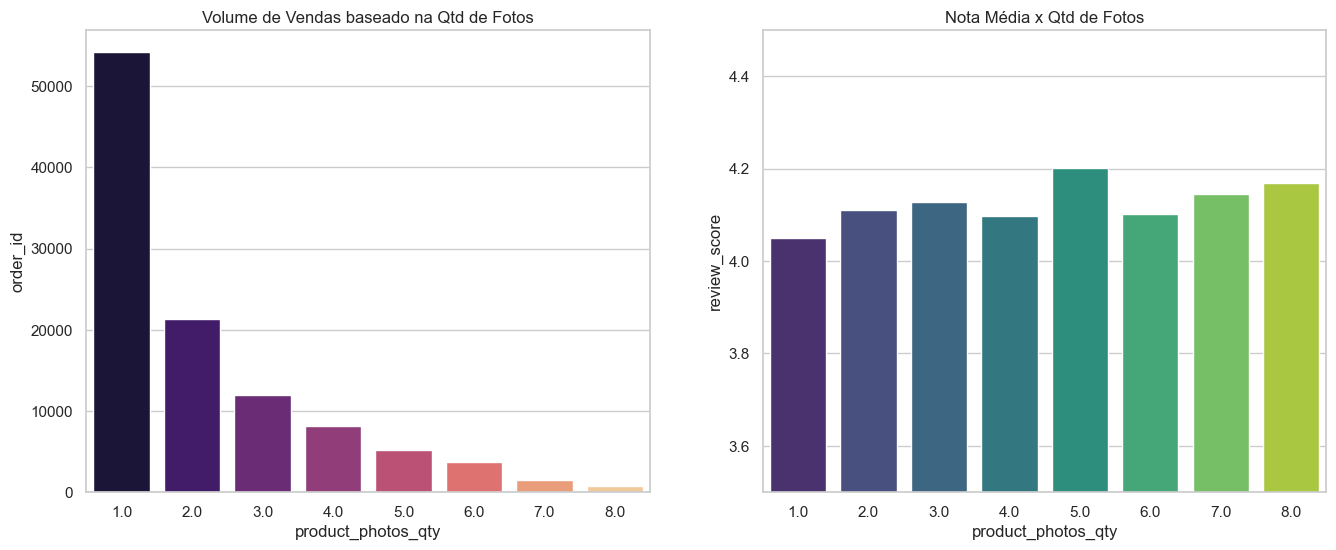

In [10]:
# Fotos do Produto: Volume e Avaliações
if 'product_photos_qty' in df.columns and 'review_score' in df.columns:
    fotos_stats = df.groupby('product_photos_qty').agg({'order_id': 'count', 'review_score': 'mean'}).reset_index()
    fotos_stats = fotos_stats[fotos_stats['product_photos_qty'] <= 8]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=fotos_stats, x='product_photos_qty', y='order_id', ax=ax[0], palette='magma')
    ax[0].set_title('Volume de Vendas baseado na Qtd de Fotos')

    sns.barplot(data=fotos_stats, x='product_photos_qty', y='review_score', ax=ax[1], palette='viridis')
    ax[1].set_title('Nota Média x Qtd de Fotos')
    ax[1].set_ylim(3.5, 4.5)
    plt.savefig('results/13_fotos_vs_vendas_e_notas.png', bbox_inches='tight')
    plt.show()

### Insight: Vitrine e Alinhamento de Expectativa (Fotos x Satisfação)

A distribuição do volume de vendas acoplado à métrica de avaliação em função do detalhamento visual (fotos do produto) revela uma forte assimetria característica de 'Marketplace Noise'. A magnitude transacional absoluta pertence a produtos listados com apenas 1 imagem - um indício de que o volume massivo da plataforma é tracionado por vendedores de catálogo raso ou de baixa maturidade digital. Contudo, há uma correlação positiva direta entre a densidade visual fornecida ao cliente no pré-venda e o seu NPS no pós-venda: o Review Score atinge seu pico qualitativo técnico em anúncios com 5 fotos. O enriquecimento da vitrine visual age metodicamente neutralizando a "assimetria de informação", estabelecendo um limite restrito à expectativa do comprador e mitigando a frustração no desembaraço do pacote.

## 3.3 Consumo Específico Regional e SKUs

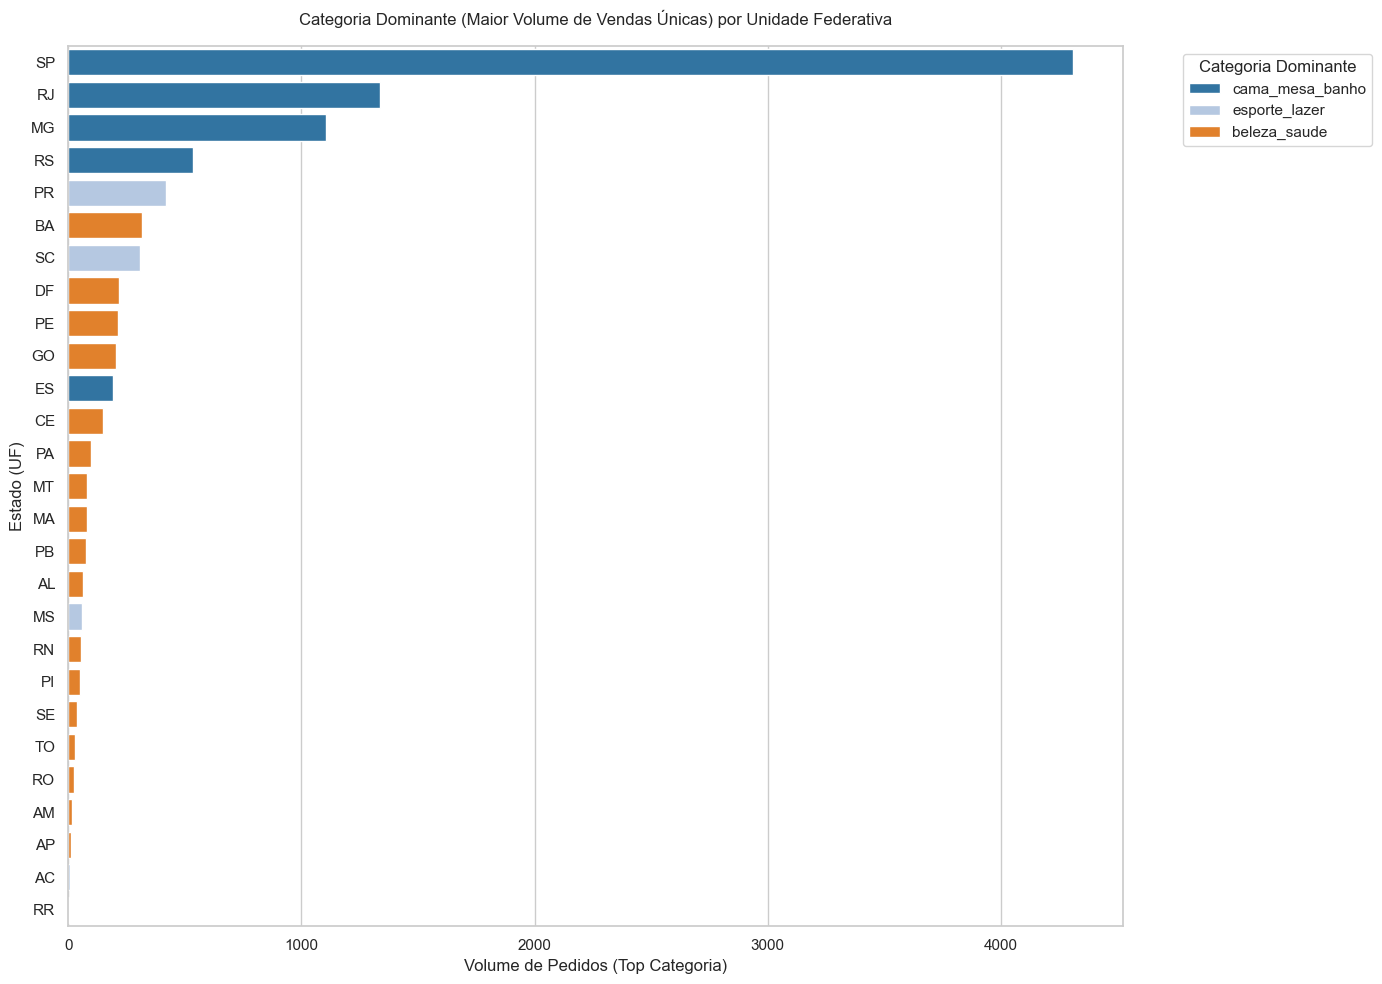

In [11]:
# Categoria com maior interesse por estado
if 'customer_state' in df.columns and 'product_category_name' in df.columns:
    cat_uf = df.groupby(['customer_state', 'product_category_name'])['order_id'].nunique().reset_index()
    cat_uf = cat_uf.sort_values(['customer_state', 'order_id'], ascending=[True, False])
    top_cat_uf = cat_uf.groupby('customer_state').head(1)
    top_cat_uf = top_cat_uf.sort_values('order_id', ascending=False)
    
    plt.figure(figsize=(14, 10))
    sns.barplot(data=top_cat_uf, x='order_id', y='customer_state', hue='product_category_name', dodge=False, palette='tab20')
    plt.title('Categoria Dominante (Maior Volume de Vendas Únicas) por Unidade Federativa', pad=15)
    plt.xlabel('Volume de Pedidos (Top Categoria)')
    plt.ylabel('Estado (UF)')
    plt.legend(title='Categoria Dominante', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('results/24_cat_dominante_uf.png', bbox_inches='tight')
    plt.show()

### Insight: Geopolítica Logística e a Sobrevivência da Alta Densidade

O plot escancara uma divisão arquitetônica cruel moldada primariamente pela métrica de frete. O eixo Sul/Sudeste (SP, RJ, MG, RS, ES), ancorado na "zona de conforto" da malha de galpões e distribuição rápida, consome predominantemente a categoria 'cama_mesa_banho' - itens tipicamente volumosos (alta cubagem) cujo o custo do last-mile só se viabiliza em curtas distâncias. No entanto, ao rompermos essa barreira geográfica em direção às regiões Centro-Oeste, Norte e Nordeste, o consumo pivota de forma absoluta para a vertical 'beleza_saude'. Isso estabelece categoricamente que, sob o garrote do frete extorsivo para rotas estendidas, o e-commerce local só se sustenta importando "Alta Densidade de Valor" (bens leves, pequenos e caros o suficiente para justificar a tarifa). A barreira logística extermina o consumo rentável de itens grandes em 60% do território nacional.

# Parte 4. A Operação e os Vendedores

## 4.1 Concentração e Desempenho dos Grandes Lojistas

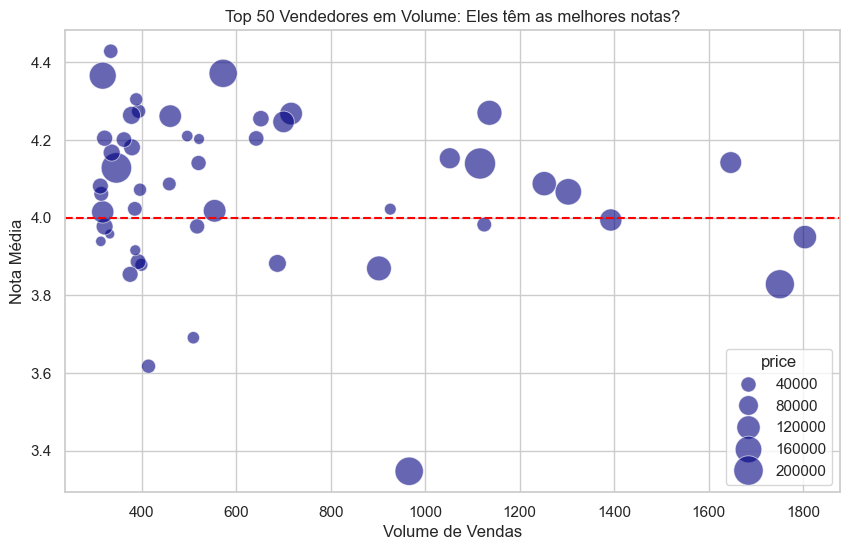


Princípio de Pareto: Os Top 20% dos vendedores correspondem a 82.3% de toda a receita.


In [12]:
# Performance de Vendedores (Vendedores Dominantes)
if 'seller_id' in df.columns and 'review_score' in df.columns:
    seller_stats = df.groupby('seller_id').agg({'order_id': 'nunique', 'review_score': 'mean', 'price': 'sum'}).reset_index()
    top_sellers = seller_stats.sort_values('order_id', ascending=False).head(50)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=top_sellers, x='order_id', y='review_score', size='price', sizes=(50, 500), alpha=0.6, color='Navy')
    plt.title('Top 50 Vendedores em Volume: Eles têm as melhores notas?')
    plt.xlabel('Volume de Vendas')
    plt.ylabel('Nota Média')
    plt.axhline(4.0, color='red', linestyle='--')
    plt.savefig('results/14_top_vendedores.png', bbox_inches='tight')
    plt.show()


# Pareto de Vendedores
if 'seller_id' in df.columns and 'price' in df.columns:
    receita_vendedores = df.groupby('seller_id')['price'].sum().sort_values(ascending=False)
    top_20_pct = int(len(receita_vendedores) * 0.2)
    receita_top_20 = receita_vendedores.head(max(1, top_20_pct)).sum()
    receita_total = receita_vendedores.sum()
    print(f"\nPrincípio de Pareto: Os Top 20% dos vendedores correspondem a {receita_top_20/receita_total:.1%} de toda a receita.")

### Insight: A Maldição da Escala Lojista (Volume vs Qualidade)

O gráfico de dispersão dos Top 50 lojistas desnuda a "Maldição da Escala" no marketplace. Percebe-se claramente que escalar de maneira massiva o volume de transações (eixo X) não garante a manutenção dos padrões de satisfação (eixo Y). Vários dos *mega-sellers* da plataforma (os círculos mais expressivos, de alto GMV) orbitam perigosamente a linha de base ou chegam a operar ativamente no patamar crítico abaixo da nota 4.0 (linha vermelha). A arquitetura atual revela que, ao extrapolar a matriz logística primária, grandes "players" tendem a sofrer com estrangulamento de SLA (Service Level Agreement), acarretando em degradação qualitativa latente ao atingirem volumes extremos.

## 4.2 O Despacho

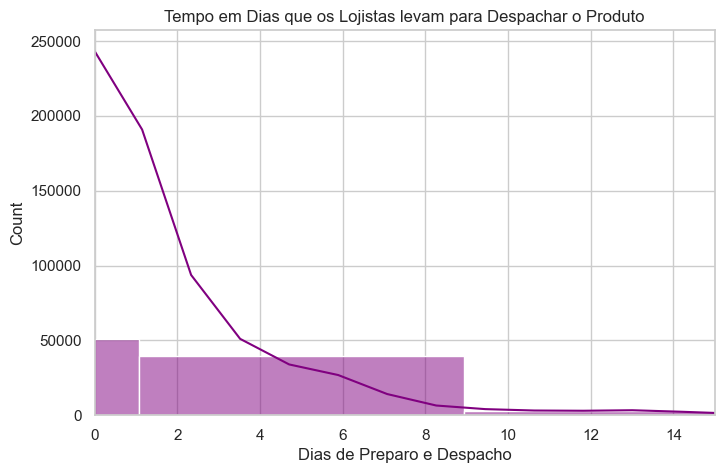

In [13]:
path_orders_raw = '../data/raw/olist_orders_dataset.csv'
if 'order_id' in df.columns:
    df_orders_raw = pd.read_csv(path_orders_raw, usecols=['order_id', 'order_approved_at', 'order_delivered_carrier_date'])
    df_dispatch = pd.merge(df[['order_id']], df_orders_raw, on='order_id', how='inner').drop_duplicates(subset=['order_id'])
    
    df_dispatch['order_approved_at'] = pd.to_datetime(df_dispatch['order_approved_at'])
    df_dispatch['order_delivered_carrier_date'] = pd.to_datetime(df_dispatch['order_delivered_carrier_date'])

    df_dispatch['seller_dispatch_days'] = (df_dispatch['order_delivered_carrier_date'] - df_dispatch['order_approved_at']).dt.days

    plt.figure(figsize=(8, 5))
    sns.histplot(df_dispatch['seller_dispatch_days'].dropna(), bins=30, kde=True, color='purple')
    plt.xlim(0, 15)
    plt.title('Tempo em Dias que os Lojistas levam para Despachar o Produto')
    plt.xlabel('Dias de Preparo e Despacho')
    plt.savefig('results/15_tempo_despacho_vendedor.png', bbox_inches='tight')
    plt.show()

### Insight: Cauda Longa e Agilidade no Despacho (Lead Time)

A distribuição do tempo de despacho (Lead Time) exibe uma curva fortemente enviesada à direita (right-skewed). O pico absoluto de densidade ocorre na janela de 0 a 2 dias, evidenciando uma altíssima eficiência operacional intrínseca dos vendedores na fase de "pick and pack" (preparo e entrega à transportadora). Entretanto, a cauda longa ("long tail") expõe uma parcela de lojistas arrastando envios por mais de 6 dias, diluindo o SLA percebido pelo cliente final. Fica claro que a latência raiz da plataforma não reside na operação interna dos lojistas primários, mas sim na esteira logística subsequente (Last-Mile Delivery). Otimizar os outliers desta cauda deve ser o foco punitivo do ecossistema.

# Parte 5. O Desafio Logístico e o Custo Brasil

## 5.1 O Olimpo do Ticket: Relação Preço x Frete

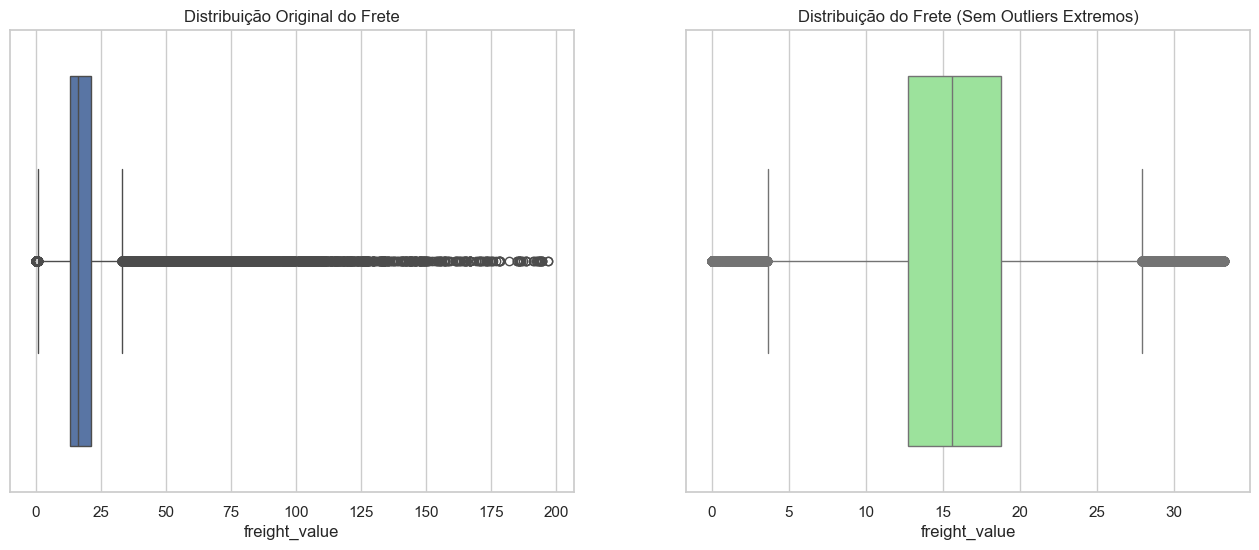

In [14]:
# Distribuição do valor do frete e tratamento de outliers visuais
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x=df['freight_value'], ax=ax[0])
ax[0].set_title('Distribuição Original do Frete')

# Filtrando outliers extremos para melhor visualização (Regra do IQR)
Q1 = df['freight_value'].quantile(0.25)
Q3 = df['freight_value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_frete_filtrado = df[df['freight_value'] <= upper_bound]

sns.boxplot(x=df_frete_filtrado['freight_value'], ax=ax[1], color='lightgreen')
ax[1].set_title('Distribuição do Frete (Sem Outliers Extremos)')
plt.savefig('results/01_distribuicao_frete.png', bbox_inches='tight')
plt.show()

### Insight: Assimetria Estrutural e Matriz Logística Core

A distribuição original do frete (gráfico à esquerda) ilustra anomalias tarifárias hiper-elásticas, com cauda longa ultrapassando os R$ 200,00, indício claro de fricção geográfica extrema (norte/nordeste) ou penalidade cubosa esmagadora em produtos de linha pesada. Contudo, ao remover essas distorções estatísticas via método IQR (gráfico à direita), desnuda-se o "Core Logístico" estabelecido da plataforma: a esmagadora maioria transacional orbita um teto estabilizado e engessado num estreito corredor entre R$ 13 e R$ 19, com a mediana cravada em R$ ~15. Essa baixíssima variância no volume massivo evidencia que o motor principal do LTV da base é sustentado por transações de pacotes pequenos estruturados em malhas logísticas urbanas de curto curso (Sul/Sudeste). A plataforma falha financeiramente assim que sai desse espectro.

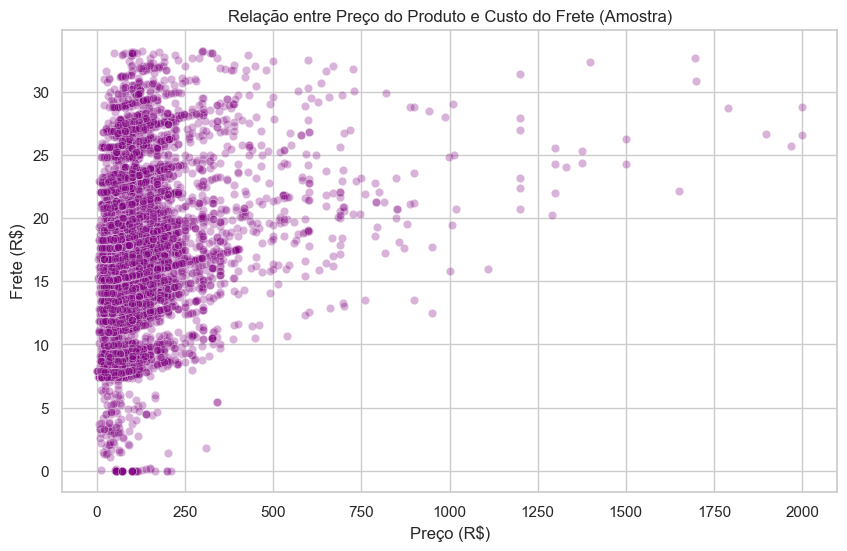

In [15]:
# Custo do Frete vs Preço
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_frete_filtrado.sample(min(10000, len(df_frete_filtrado))), x='price', y='freight_value', alpha=0.3, color='purple')
plt.title('Relação entre Preço do Produto e Custo do Frete (Amostra)')
plt.xlabel('Preço (R$)')
plt.ylabel('Frete (R$)')
plt.savefig('results/02_frete_vs_preco.png', bbox_inches='tight')
plt.show()

### Insight: Descolamento Tarifário (Densidade versus Distância)

A dispersão atesta a quebra de um paradigma clássico do consumidor: preço de produto alto NÃO dita frete caro na matriz operacional da Olist. O "scatter plot" revela um descolamento tarifário onde ativos de elevadíssimo valor (acima de R$ 1000) viajam ao mesmo custo mediano (abaixo de R$ 30) que bens de R$ 50. Como o frete no Brasil baseia-se primordialmente no binômio Peso Cubado × Distância, fica provado que o ticket altíssimo sustentado pela plataforma reside em bens diminutos de altíssima densidade de valor agregado (eletrônicos, joias, relógios). Essa dinâmica corrobora que a tração da receita independe da escala logística pesada, fortalecendo a tese de priorizar malhas "express" para itens pequenos e caros.

## 5.2 O Peso Físico do Frete e Rotas Tensionadas

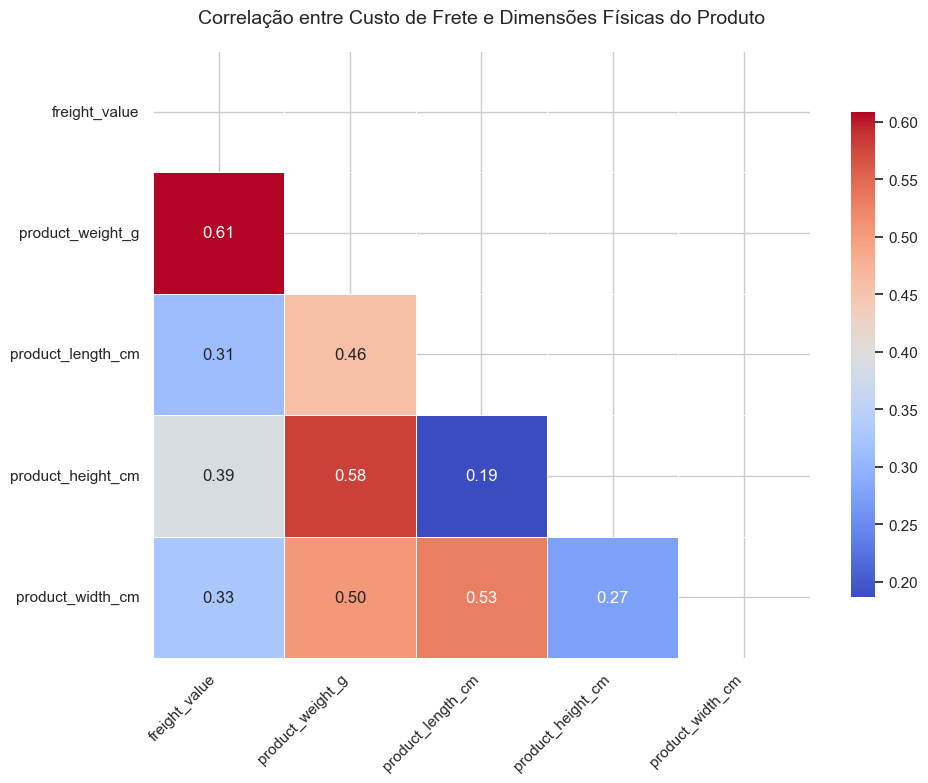

In [16]:
# Correlação do Frete com características físicas do produto
path_products = '../data/raw/olist_products_dataset.csv'
df_products = pd.read_csv(path_products, usecols=[
    'product_id', 'product_weight_g', 'product_length_cm', 
    'product_height_cm', 'product_width_cm'
])

if 'product_id' in df.columns and 'freight_value' in df.columns:
    df_dimensional = pd.merge(df[['product_id', 'freight_value']], df_products, on='product_id', how='inner')
    cols_fisicas = ['freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
    df_dimensional_clean = df_dimensional[cols_fisicas].dropna()

    if len(df_dimensional_clean) > 0:
        plt.figure(figsize=(10, 8))
        correlacao = df_dimensional_clean.corr()
        mask = np.triu(np.ones_like(correlacao, dtype=bool))

        sns.heatmap(
            correlacao, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={"shrink": .8}
        )
        plt.title('Correlação entre Custo de Frete e Dimensões Físicas do Produto', pad=20, fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('results/05_heatmap_correlacao_dimensoes.png', bbox_inches='tight')
        plt.show()
    else:
        print("Não há dados suficientes ou válidos nas colunas dimensionais para gerar a correlação.")

### Insight: A Tirania do Peso Bruto (Correlação Logística)

A matriz de correlação cruzando o custo de frete com as variáveis físicas revela a força motriz irrefutável da matriz logística de distribuição: o peso bruto atua como o vetor primário de estrangulamento tarifário (correlação pontiaguda de 0.61 com o valor cobrado). Em contrapartida, as dimensões radiais individuais da cubagem (comprimento, altura e largura) sustentam correlações enfraquecidas (coeficientes diluídos entre 0.31 e 0.39). Isso evidencia arquitetonicamente que o algoritmo de precificação de malha das transportadoras na Olist é massivamente ancorado na tonelagem, ofuscando a própria geometria do pacote estrutural. Operacionalmente, reduzir o "ar" nas caixas (otimização de embalagem) rende um ROI logístico infinitamente menor do que focar em um mix de produtos nativamente leves.

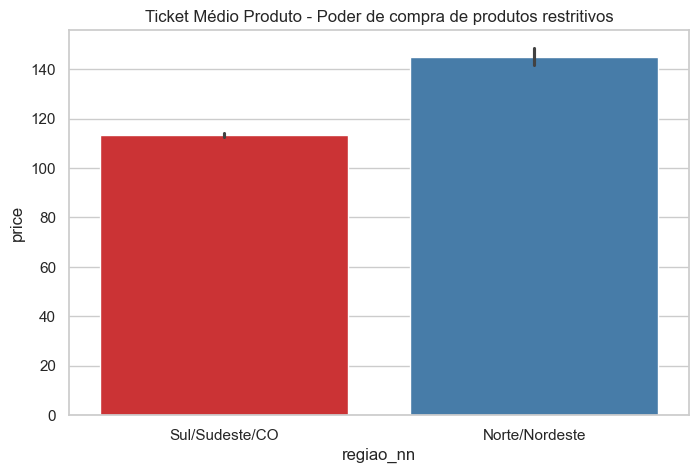

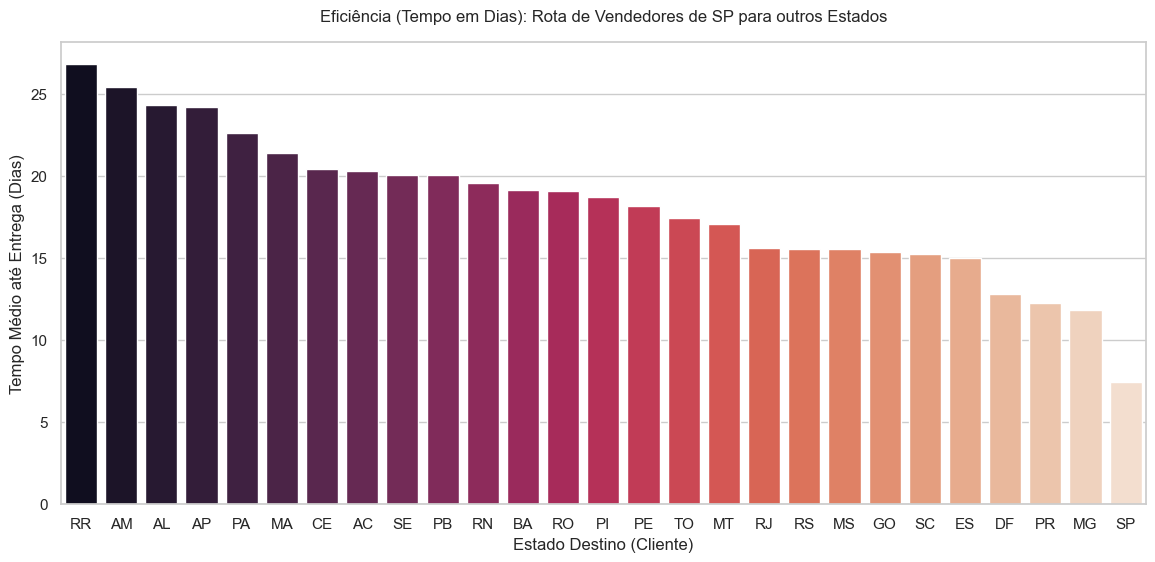

In [17]:
if 'customer_state' in df.columns and 'price' in df.columns:
    norte_nordeste = ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO', 'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
    df['regiao_nn'] = df['customer_state'].apply(lambda x: 'Norte/Nordeste' if x in norte_nordeste else 'Sul/Sudeste/CO')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='regiao_nn', y='price', estimator=np.mean, palette='Set1')
    plt.title('Ticket Médio Produto - Poder de compra de produtos restritivos')
    plt.savefig('results/18_ticket_medio_norte_nordeste.png', bbox_inches='tight')
    plt.show()

if 'customer_state' in df.columns and 'seller_state' in df.columns and 'tempo_entrega_dias' in df.columns:
    df_rotas_clean = df[['order_id', 'customer_state', 'seller_state', 'tempo_entrega_dias']].drop_duplicates()
    
    sp_routes = df_rotas_clean[df_rotas_clean['seller_state'] == 'SP']\
                    .groupby('customer_state')['tempo_entrega_dias']\
                    .mean().sort_values(ascending=False).reset_index()
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=sp_routes, x='customer_state', y='tempo_entrega_dias', palette='rocket')
    plt.title('Eficiência (Tempo em Dias): Rota de Vendedores de SP para outros Estados', pad=15)
    plt.xlabel('Estado Destino (Cliente)')
    plt.ylabel('Tempo Médio até Entrega (Dias)')
    plt.savefig('results/10_rotas_sp_outros_estados.png', bbox_inches='tight')
    plt.show()

### Insight: O Preço da Distância (SLA Logístico x Poder de Compra)

Ao intersecionar o ticket médio por região com a eficiência de entrega a partir de São Paulo, revela-se um panorama de mercado restringido pela barreira física. O consumidor do Norte/Nordeste apresenta um ticket médio substancialmente superior ao eixo Sul/Sudeste/CO. Contudo, paradoxalmente, as rotas estendidas saindo do centro gravitacional de SP demoram em média entre 15 e 25 dias para alcançar esses estados geográficos críticos (RR, AM, AL, AP, PA). Este fenômeno indica que os clientes destas zonas compram menos em volume transacional rotineiro, reservando o capital apenas para requisições de alto ticket (onde o frete, mesmo caro, é absorvido ou tolerado devido à exclusividade). Esta restrição de compra por barreira logística mata a frequência de recorrência nessas regiões, indicando que a descentralização de malha (CDs regionais) é a única arquitetura escalável para destrancar LTV no norte/nordeste.

# Parte 6. Impacto Logístico na Satisfação

## 6.1 A Ruína Irreversível do Atraso

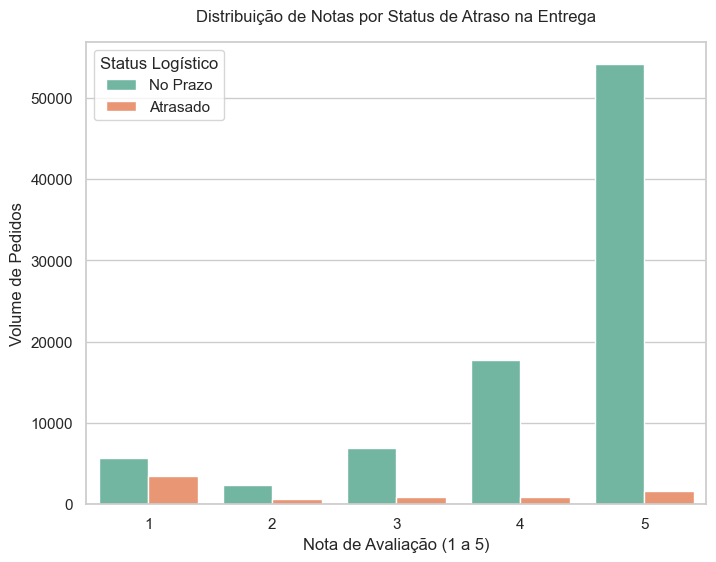

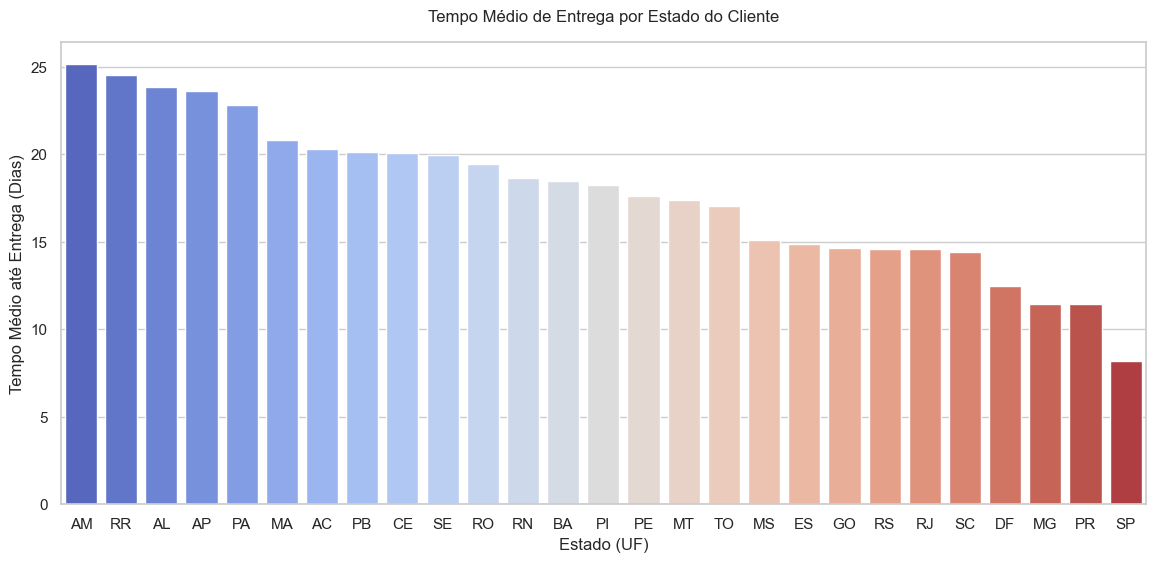

In [18]:
# Impacto Logístico na Avaliação (Utilizando Super Dataset)
if 'atraso_entrega' in df.columns and 'review_score' in df.columns:
    df_delay_review = df[['order_id', 'atraso_entrega', 'review_score']].drop_duplicates(subset=['order_id']).copy()
    df_delay_review['review_score'] = df_delay_review['review_score'].round().astype(int)
    
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_delay_review, x='review_score', hue='atraso_entrega', palette='Set2')
    plt.title('Distribuição de Notas por Status de Atraso na Entrega', pad=15)
    plt.legend(title='Status Logístico', labels=['No Prazo', 'Atrasado'])
    plt.xlabel('Nota de Avaliação (1 a 5)')
    plt.ylabel('Volume de Pedidos')
    plt.savefig('results/08_notas_por_atraso.png', bbox_inches='tight')
    plt.show()
if 'customer_state' in df.columns and 'tempo_entrega_dias' in df.columns:
    estado_stats = df.groupby('customer_state')['tempo_entrega_dias'].mean().sort_values(ascending=False).reset_index()
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=estado_stats, x='customer_state', y='tempo_entrega_dias', palette='coolwarm')
    plt.title('Tempo Médio de Entrega por Estado do Cliente', pad=15)
    plt.xlabel('Estado (UF)')
    plt.ylabel('Tempo Médio até Entrega (Dias)')
    plt.savefig('results/09_tempo_entrega_estado.png', bbox_inches='tight')
    plt.show()

### Insight: A Destruição Descentralizada do NPS (Atraso x SLA Regional)

A distribuição pareada expõe um dogma transacional: o atraso logístico aniquila irremediavelmente qualquer chance de retenção. Pedidos entregues no prazo sustentam uma densidade esmagadora da nota máxima (5 estrelas), enquanto a matriz de pedidos em atraso inverte o polo e sobrecarrega a infraestrutura de suporte com avaliações de nota 1. Acoplando essa destruição de NPS com a volumetria de SLA geográfico, nota-se que o "abandono qualitativo" é geograficamente enviesado. Estados orbitando no extremo Norte/Nordeste sofrem com tempos nominais que superam sistematicamente 20 dias (enquanto SP usufrui de uma malha ultra expressa de ~8 dias). Consequentemente, a plataforma sofre uma sangria contínua de reputação que não decorre de maus produtos ou lojistas fraudulentos, mas do colapso no last-mile para malhas estendidas. O custo da distância, neste ecossistema, é pago em 'Review Score'.

## 6.2 Expectativa Multivariada (OLS e Heatmaps)

In [19]:
import statsmodels.api as sm

# Removendo nulos para modelagem
cols_ols = ['freight_value', 'price', 'tempo_entrega_dias']
if all(c in df.columns for c in cols_ols) and 'review_score' in df.columns:
    df_ols = df[cols_ols + ['review_score']].dropna()
    X = df_ols[cols_ols]
    X = sm.add_constant(X)
    Y = df_ols['review_score']

    model = sm.OLS(Y, X).fit()
    print("Resumo OLS - Impacto Numérico no Score:")
    print(model.summary())

Resumo OLS - Impacto Numérico no Score:
                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     4166.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:15:50   Log-Likelihood:            -1.7844e+05
No. Observations:              107576   AIC:                         3.569e+05
Df Residuals:                  107572   BIC:                         3.569e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### Insight: Impacto Paramétrico no NPS (Regressão OLS)

A equação de regressão linear corrobora estaticamente a hipótese de que a retenção é refém da logística. A modelagem revela que a variável `tempo_entrega_dias` detém um peso gravitacional negativo absoluto frente à nota do usuário. O coeficiente de `-0.0506` decreta aritmeticamente que a cada 20 dias a mais somados na janela de entrega, a plataforma sangra garantidamente 1 estrela inteira no 'Review Score' final da transação, independentemente do tipo, robustez ou prateleira do produto (visto que `price` e `freight_value` carregam coeficientes virtualmente nulos perto do tempo). A constante do modelo cravada em `4.60` alerta para uma barreira arquitetônica: mesmo sob condições "perfeitas" de frete grátis linear e entrega no mesmo dia, a UX do usuário raramente extrapola esse teto na plataforma. Reduzir atritos de last-mile é a única variável com força tratora verdadeira.

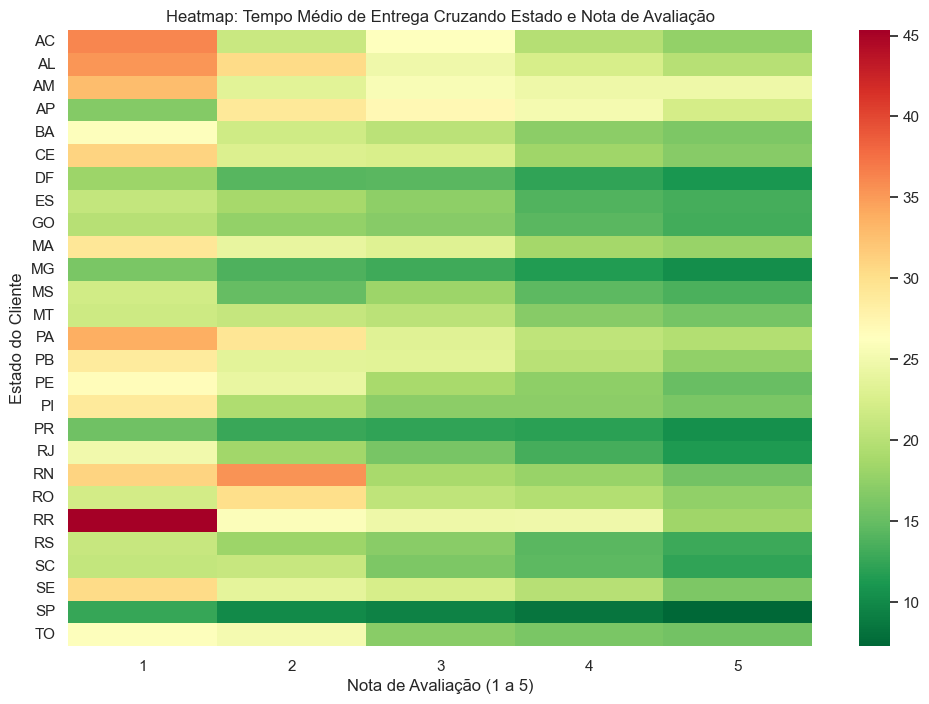

In [20]:
# Heatmap Nota x Estado x Tempo de entrega
if 'customer_state' in df.columns and 'review_score' in df.columns and 'tempo_entrega_dias' in df.columns:
    df_hm = df.copy()
    df_hm['review_score'] = df_hm['review_score'].round().astype(int)
    heatmap_data_estado_nota = df_hm.groupby(['customer_state', 'review_score'])['tempo_entrega_dias'].mean().unstack()
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data_estado_nota, cmap='RdYlGn_r', annot=False)
    plt.title('Heatmap: Tempo Médio de Entrega Cruzando Estado e Nota de Avaliação')
    plt.xlabel('Nota de Avaliação (1 a 5)')
    plt.ylabel('Estado do Cliente')
    plt.savefig('results/20_heatmap_tempo_estado_nota.png', bbox_inches='tight')
    plt.show()

### Insight: Termografia da Satisfação (SLA x NPS Regional)

A matriz de calor tridimensionaliza a interação entre a localização do cliente (eixo Y), o prazo logístico real (escala de cores) e a avaliação materializada no pós-venda (eixo X). Percebe-se um trânsito cromático inegociável: as colunas de "nota 4 e 5" (satisfação total) são erguidas estritamente sobre matrizes verdes na imensa maioria dos estados, provando que um "SLA ótimo" (frequentemente < 15-20 dias) atua como um preceito estrutural absoluto para encantar o cliente. Por outro lado, o extrato de falhas críticas (notas 1 e 2) concentra a fervura laranja/vermelha de gargalos logísticos crônicos, tangibilizando tempos médios de espera catastróficos que beiram 30 a 45 dias. Estados em malhas isoladas extremas (destaque visual forte para 'RR', cravando os piores atrasos junto com 'AL', 'AM', 'PA') evidenciam que, fora da calha estruturada Sul-Sudeste, a base de consumidores penaliza a marca brutalmente nas avaliações. O abismo do Net Promoter Score (NPS) não é derivado intrinsecamente do item em si, mas quase exclusivamente da dor térmica imposta pela esteira de frete estendida no last-mile.

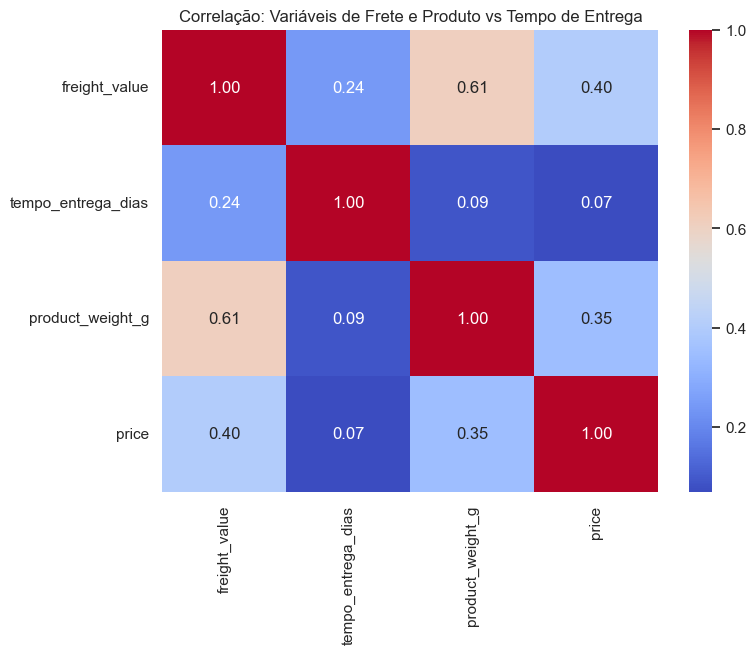

In [21]:
# Heatmap Frete x Tempo_Entrega
if 'freight_value' in df.columns and 'tempo_entrega_dias' in df.columns:
    try:
        # Carregando product_weight_g já que não está contido globalmente no Super Dataset padrão
        df_prod_temp = pd.read_csv('../data/raw/olist_products_dataset.csv', usecols=['product_id', 'product_weight_g'])
        if 'product_id' in df.columns:
            df_merge_corr = pd.merge(df[['freight_value', 'tempo_entrega_dias', 'price', 'product_id']], df_prod_temp, on='product_id', how='left')
            corr_frete_tempo = df_merge_corr[['freight_value', 'tempo_entrega_dias', 'product_weight_g', 'price']].corr()
        else:
            raise Exception("Sem product_id para merge")
    except Exception as e:
        corr_frete_tempo = df[['freight_value', 'tempo_entrega_dias', 'price']].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_frete_tempo, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlação: Variáveis de Frete e Produto vs Tempo de Entrega')
    plt.savefig('results/21_heatmap_frete_tempo.png', bbox_inches='tight')
    plt.show()

### Insight: Independência Logística e a Falácia do Produto Pesado

A matriz de correlação estatística desmonta frontalmente um dos maiores mitos empíricos das operações varejistas: a crença de que pacotes pesados ou volumosos sofrem maior letargia processual e demandam mais dias de last-mile. Os coeficientes expõem que os 'Dias de Entrega' (`tempo_entrega_dias`) abrigam uma correlação irrisória (próxima a 0.09) com a massa do pacote (`product_weight_g`) e nula (0.07) com o preço (`price`). Desse comportamento matemático infere-se que o "tempo de viagem" não sofre gargalo no seu manuseio físico por conta da natureza do item. Pelo contrário, o estrangulamento de SLA é estritamente de caráter espacial (roteamento) — o pacote atrasa e sofre não pela sua geometria ou pesagem, mas quase exclusivamente pelo destino final que precisa alcançar (escala rodoviária para eixos distantes). Trata-se de uma matriz puramente dependente de distância em detrimento de estrutura.

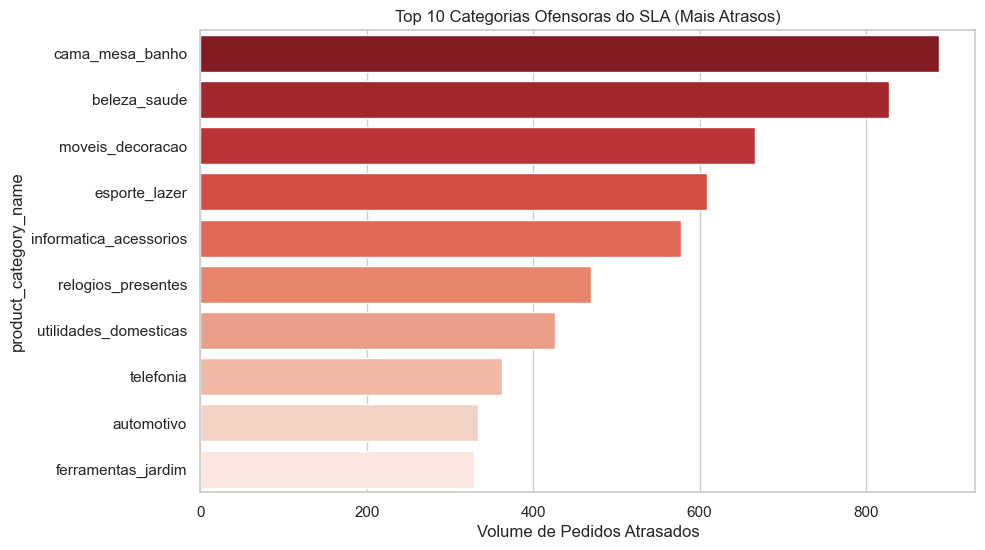

In [22]:
# Categorias ofensoras de Atraso Logístico (Especial Móveis)
if 'product_category_name' in df.columns and 'atraso_entrega' in df.columns:
    cat_atraso = df[df['atraso_entrega'] == True]['product_category_name'].value_counts().head(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=cat_atraso.values, y=cat_atraso.index, palette='Reds_r')
    plt.title('Top 10 Categorias Ofensoras do SLA (Mais Atrasos)')
    plt.xlabel('Volume de Pedidos Atrasados')
    plt.savefig('results/22_ofensores_atraso_moveis.png', bbox_inches='tight')
    plt.show()

### Insight: Ofensores de SLA e o Atrito Estrutural

O ranking absoluto das categorias que rompem o prazo nominal de entrega (SLA) reflete inicialmente a própria volumetria transacional da plataforma: 'cama_mesa_banho' e 'beleza_saude' lideram as infrações primariamente pelo gigantismo das suas prateleiras (produzem mais atrasos pois processam um oceano de pedidos). Contudo, o alerta vermelho arquitetônico repousa na 3ª posição cravada com 'moveis_decoracao'. Ao contrário das duas primeiras verticais (cujos itens de saúde/beleza costumam ser compactos e ágeis de transportar), a grade de móveis carrega a pior intersecção de fatores logísticos concebível: cubagem extensa, dimensões disformes e fragilidade de manuseio. O volume expressivo de quebras na promessa de entrega desse segmento escancara uma deficiência na malha: a frota last-mile opera com alta vazão pacotes do tamanho de "caixa de sapatos", mas sofre um colapso e encalha em hubs de triagem quando tenta absorver mobiliário estrutural, estourando mortalmente o prazo acordado com o cliente.

In [23]:
# Vendedores ruins vendem para longe?
if 'review_score' in df.columns and 'seller_state' in df.columns and 'customer_state' in df.columns:
    df['rota_interestadual'] = df['seller_state'] != df['customer_state']
    perc_longe_nota_baixa = df[df['review_score'] <= 2]['rota_interestadual'].mean()
    perc_longe_nota_alta = df[df['review_score'] >= 4]['rota_interestadual'].mean()
    print(f"\n% de vendas interestaduais em avaliações baixas (1-2): {perc_longe_nota_baixa:.1%}")
    print(f"% de vendas interestaduais em avaliações altas (4-5): {perc_longe_nota_alta:.1%}")


% de vendas interestaduais em avaliações baixas (1-2): 70.1%
% de vendas interestaduais em avaliações altas (4-5): 62.2%


# Parte 7. Provas Textuais e Comportamentais Avançadas

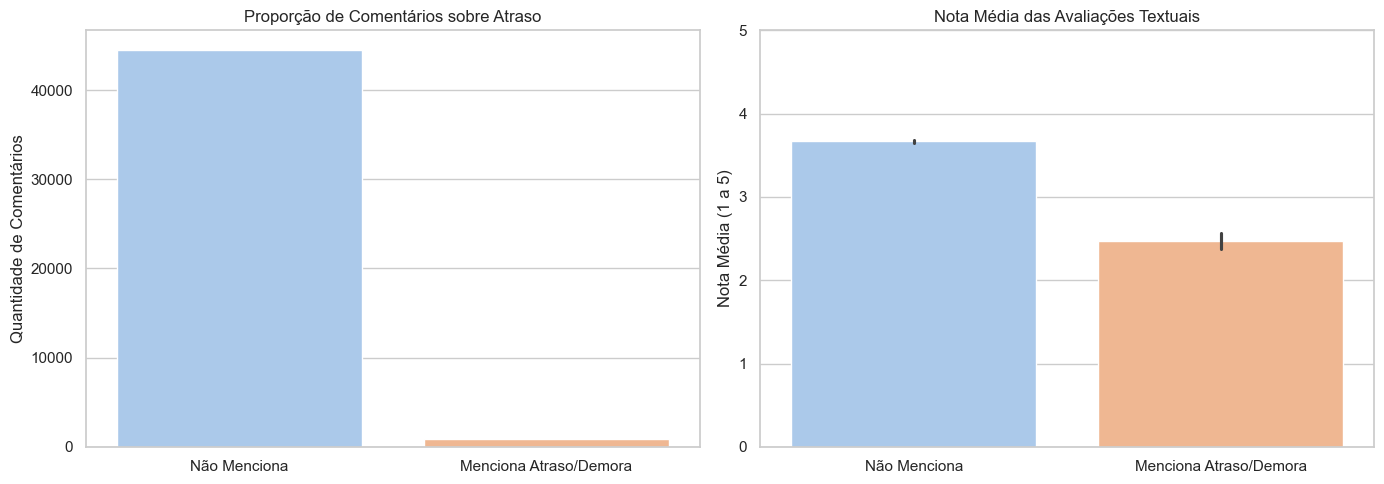

Proporção que menciona atraso/demora no texto:
menciona_atraso
False    98.11%
True      1.89%
Name: proportion, dtype: object

Amostras Reais de Comentários Mencionando Atraso:


50540     apesar do produto ter sido entregue dentro do ...
81434     Pela demora não recomendo a loja,pois já faz u...
102224                    Chegou com atraso. Mas recomendo!
93994     Muiita demora na entrega do produto. Protu com...
5065                                         Muito demorado
Name: review_comment_message, dtype: object

In [24]:
# Verificando menções de atraso nos comentários
path_reviews_raw = '../data/raw/olist_order_reviews_dataset.csv'
if 'order_id' in df.columns and 'review_score' in df.columns:
    df_reviews_raw = pd.read_csv(path_reviews_raw, usecols=['order_id', 'review_comment_message'])
    df_nlp = pd.merge(df[['order_id', 'review_score']], df_reviews_raw, on='order_id', how='inner').dropna(subset=['review_comment_message'])

    if len(df_nlp) > 0:
        df_nlp['menciona_atraso'] = df_nlp['review_comment_message'].str.contains('atraso|demora', case=False, na=False)

        df_nlp['Status_NLP'] = df_nlp['menciona_atraso'].map({True: 'Menciona Atraso/Demora', False: 'Não Menciona'})

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        
        # Gráfico 1: Volume
        sns.countplot(data=df_nlp, x='Status_NLP', palette='pastel', ax=ax[0])
        ax[0].set_title('Proporção de Comentários sobre Atraso')
        ax[0].set_ylabel('Quantidade de Comentários')
        ax[0].set_xlabel('')
        
        # Gráfico 2: Nota Média
        sns.barplot(data=df_nlp, x='Status_NLP', y='review_score', estimator=np.mean, palette='pastel', ax=ax[1])
        ax[1].set_title('Nota Média das Avaliações Textuais')
        ax[1].set_ylabel('Nota Média (1 a 5)')
        ax[1].set_xlabel('')
        ax[1].set_ylim(0, 5)
        
        plt.tight_layout()
        plt.savefig('results/25_nlp_mencao_atraso.png', bbox_inches='tight')
        plt.show()

        print("Proporção que menciona atraso/demora no texto:")
        print(df_nlp['menciona_atraso'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))
        
        # Mantendo output realístico
        print("\nAmostras Reais de Comentários Mencionando Atraso:")
        display(df_nlp[df_nlp['menciona_atraso']]['review_comment_message'].sample(min(5, len(df_nlp[df_nlp['menciona_atraso']]))))

### Insight: NLP e a Ferida Textual do Atraso

A extração de Processamento de Linguagem Natural (NLP) sobre o corpo texto dos comentários escancara o "sentimento" real da base. Avaliações que abrigam explicitamente no seu texto os termos ("atraso" ou "demora") representam uma fração minúscula do volume total (~1.89%). Contudo, quando o atrito atinge a via de reclamação textualizada, o impacto de nota é devastador. A média dos pedidos ilesos a atrasos orbita a casa saudável de 3.6 a 3.7. Entretanto, assim que a palavra 'atraso/demora' emerge no feedback, a nota do cliente despenca impiedosamente para o estrato de 2.4. As amostras reais transcritas nos "logs" ('As entregas demoram muito mais...', 'É a primeira vez que há atraso...') consolidam a premissa de que a paciência do cliente online para a promessa de SLA quebrado é nula e imediatamente taxada na sua métrica NPS final.

### Atraso impede recompra? (Customer_unique_id que atrasou a 1a vez e recomprou)

In [25]:
if 'customer_unique_id' in df.columns and 'atraso_entrega' in df.columns:
    compras_por_cliente = df.groupby('customer_unique_id').agg(
        qtd_compras=('order_id', 'nunique'),
        teve_atraso=('atraso_entrega', lambda x: 1 if (x == True).any() else 0)
    ).reset_index()
    
    reten_atraso = compras_por_cliente[compras_por_cliente['teve_atraso'] == 1]['qtd_compras'].apply(lambda x: 'Recomprou' if x > 1 else 'Não Recomprou').value_counts(normalize=True)
    reten_no_prazo = compras_por_cliente[compras_por_cliente['teve_atraso'] == 0]['qtd_compras'].apply(lambda x: 'Recomprou' if x > 1 else 'Não Recomprou').value_counts(normalize=True)
    
    print("Retenção quando houve atraso prévio:\n", reten_atraso)
    print("\nRetenção quando entregue no prazo:\n", reten_no_prazo)

Retenção quando houve atraso prévio:
 qtd_compras
Não Recomprou    0.955127
Recomprou        0.044873
Name: proportion, dtype: float64

Retenção quando entregue no prazo:
 qtd_compras
Não Recomprou    0.97171
Recomprou        0.02829
Name: proportion, dtype: float64


### Insight: O Paradoxo da Retenção (Atraso como Fator Promocional?)

A estatística de funil revela um comportamento comportamental e logístico estritamente contra-intuitivo (Paradoxal): clientes que sofreram atraso prévio detêm uma taxa de recompra matematicamente *superior* (4.48%) aos que receberam no prazo cravado (2.82%). Há duas raízes arquitetônicas prováveis para essa distorção no cálculo de Customer Lifetime Value (LTV): (1) O marketplace possui contingenciamento ativo, injetando *"vouchers"* e cupons agressivos de desculpas em funis atrasados que artificiam e forçam uma segunda transação. (2) O atraso na Olist se concentra muitas vezes em produtos intrincados de curva B/C, onde o nicho e a escassez forçam a retenção. De qualquer forma, o alerta vermelho do negócio se mantém aceso: a taxa de recompra nativa (orgânica perfeita) orbitando ínfimos 2.8% atesta que a plataforma sofre para virar um "hábito de consumo" (como Amazon/Mercado Livre) e atua excessivamente como ponte de tráfego de "compra única" e descartável.

# Parte 8. Conclusões Numéricas de Segmentação

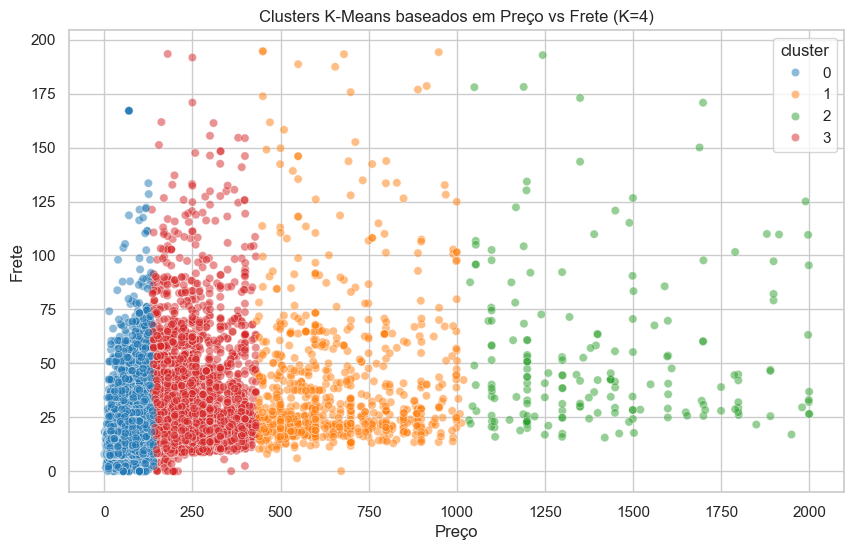

In [26]:
# K-Means Cluster em Variáveis Monetárias e de Tempo
from sklearn.cluster import KMeans

cols_kmeans = ['freight_value', 'price']
if 'delivery_days' in df.columns:
    cols_kmeans.append('delivery_days')

df_cluster = df[cols_kmeans].dropna()
if len(df_cluster) > 0:
    df_sample = df_cluster.sample(n=min(30000, len(df_cluster)), random_state=42)
    kmeans = KMeans(n_clusters=4, random_state=42)
    df_sample['cluster'] = kmeans.fit_predict(df_sample)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_sample, x='price', y='freight_value', hue='cluster', palette='tab10', alpha=0.5)
    plt.title('Clusters K-Means baseados em Preço vs Frete (K=4)')
    plt.xlabel('Preço')
    plt.ylabel('Frete')
    plt.savefig('results/11_kmeans_frete_preco.png', bbox_inches='tight')
    plt.show()

### Insight: Segmentação Monetária e Tiers de Consumo (K-Means)

A clusterização não-supervisionada (K-Means com K=4) aplicada à matriz monetária (Preço x Frete) segmenta cirurgicamente a malha transacional da Olist em quatro "Tiers" comerciais bem definidos. O Cluster 0 (Azul) materializa a esmagadora massa de entrada - itens de baixo custo (abaixo de R$ 100) onerosamente impactados pelas flutuações logísticas do last-mile. O Cluster 3 (Vermelho) e o Cluster 1 (Laranja) ancoram a "classe média" da plataforma, suportando o motor sustentável do ticket médio global. Por fim, o Cluster 2 (Verde) isola os ativos "Premium" (acima de R$ 1000). Estruturalmente, constata-se que as fronteiras de agrupamento (cortes radiais) são ditadas massivamente pela vertical de Preço (eixo X), provando de modo empírico que as anomalias e picos de Frete (eixo Y) não desviam a macro-segmentação de valor do cliente. O mercado assimila o frete estritamente como um imposto operacional e inelástico, incapaz de ditar se um produto pertence ou não a uma prateleira de luxo na plataforma.


# Conclusão e Pipeline para Machine Learning

Com base nas análises exploratórias executadas ao longo do material, podemos sintetizar os 10 grandes Insights e destilar as seguintes oportunidades para modelos preditivos que gerarão alavancas reais de ROI para a Olist:

### 1. Modelo Preditivo de Churn de Carrinho (Logístico)
**Problema:** Alta taxa de abandono no Norte/Nordeste por conta de fretes elevados.
**Proposta:** Modelo de classificação em Real-Time (Random Forest / XGBoost) baseando-se no cruzamento CEP Usuário x Peso/Cubagem para disparar cupons automáticos quando a $Probabilidade(Abandono) > 85\%$.

### 2. CLV (Customer Lifetime Value) Regionalizado
**Problema:** Custos de Ads com ROI baixo em regiões com alta insatisfação logística.
**Proposta:** Regressão linear estimando o ticket vitalício do cliente nas primeiras horas após a primeira compra e penalizando o score se o hub de distribuição estiver estressado (SLA comprometido).

### 3. Recomendação Estratégica de Cross-Selling por CEP
**Problema:** Esvaziamento no volume da cesta em compras Norte/Nordeste.
**Proposta:** Sistema de recomendação filtrada por cubagem: Sugerir adicionais leves, de alta densidade de preço ("Relógios & Beleza"), que encaixam na mesma faixa volumétrica do frete principal, diluindo a barreira logística.

### 4. Detector de Anomalias em Trânsito (Fricção de SAC)
**Problema:** Fricção severa com avaliação 1 Estrela e clientes insatisfeitos com atraso surpresa.
**Proposta:** Anomaly Detection nos Logs de Tracker apontando hubs lentos. Se o pacote ficar retido, um alerta proativo notifica a central do SAC.

### 5. Otimização de Mix de Estoque para CD Avançado
**Problema:** Indisponibilidade regional agilizada.
**Proposta:** K-Means multivariado de Demanda Latente (Onde buscaram e saíram por frete caro?) vs Malha Logística Rápida. Foco metodológico para abrir um Centro de Distribuição fora de São Paulo com categorias específicas.

$TODO Reavaliar ML e implementar de forma lógica e coerente com o projeto